In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("student_performance.csv")
print("Boyut:", df.shape)
df.head()

Boyut: (1020, 7)


,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade
0,S0524,21,Female,2.7,74.0,37.0,F
1,S0603,19,Male,1.5,93.1,26.0,F
2,S0527,20,Female,6.8,97.2,88.0,A
3,S0032,18,Female,6.2,93.5,55.0,C
4,S0617,21,Male,7.4,99.2,77.0,B


In [4]:
# ── Eksik değer analizi (dersteki gibi) ──────────────────────────────────
print(df.isnull().sum())
print()
df.describe().round(2)

Student_ID        0
Age               0
Gender            0
Study_Hours      31
Attendance(%)    30
Test_Score        0
Grade             9
dtype: int64



,Age,Study_Hours,Attendance(%),Test_Score
count,1020.00,989.00,990.00,1020.00
mean,20.97,5.16,84.87,49.84
std,2.01,2.56,10.01,21.28
min,18.00,-2.00,50.30,0.00
25%,19.00,3.70,78.00,35.00
50%,21.00,5.10,85.00,50.00
75%,23.00,6.30,91.98,64.00
max,24.00,25.00,115.60,100.00


In [5]:
# ── 1) Duplicate kayıtlar ────────────────────────────────────────────────
print("Tamamen aynı satır sayısı:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate temizliği sonrası:", df.shape)

Tamamen aynı satır sayısı: 20
Duplicate temizliği sonrası: (1000, 7)


In [6]:
# ── 2) Eksik değerler ────────────────────────────────────────────────────
# Modelimizin x'i Study_Hours, y'si Test_Score. x'i eksik olan satırı DOLDURMAK yerine
# SİLİYORUZ: x-y ilişkisinin şeklini öğrenmeye çalışırken x'i uydurmak ilişkiyi bozar.
df = df.dropna(subset=["Study_Hours"]).reset_index(drop=True)

# Attendance'ı modelde kullanmayacağız ama tabloyu tam tutmak için medyanla dolduruyoruz
df["Attendance(%)"] = df["Attendance(%)"].fillna(df["Attendance(%)"].median())

print("Eksik değer temizliği sonrası:", df.shape)
print(df[["Study_Hours", "Attendance(%)"]].isnull().sum())

Eksik değer temizliği sonrası: (970, 7)
Study_Hours      0
Attendance(%)    0
dtype: int64


In [7]:
# ── 3) Mantıksal hatalar ─────────────────────────────────────────────────
# Negatif ya da 24 saati aşan çalışma süresi fiziksel olarak imkânsız -> sil
imkansiz = df[(df["Study_Hours"] < 0) | (df["Study_Hours"] > 24)]
print("İmkânsız çalışma saati olan satırlar:")
print(imkansiz[["Student_ID", "Study_Hours", "Test_Score"]].to_string(index=False))

df = df[(df["Study_Hours"] >= 0) & (df["Study_Hours"] <= 24)].reset_index(drop=True)

# Devam yüzdesi 100'ü aşamaz -> 100'e kırpıyoruz (ölçüm/giriş hatası varsayımı)
tasan = (df["Attendance(%)"] > 100).sum()
df["Attendance(%)"] = df["Attendance(%)"].clip(upper=100)
print(f"\n%100'ü aşan {tasan} devam değeri 100'e kırpıldı")
print("Son boyut:", df.shape)

İmkânsız çalışma saati olan satırlar:
Student_ID  Study_Hours  Test_Score
     S0045         -2.0         4.0
     S0536         25.0        24.0
     S0959         25.0        49.0
     S0689         -0.5         6.0
     S0489         25.0         7.0
     S0497         -0.8         0.0
     S0225         25.0        62.0
     S0725         -0.7         0.0

%100'ü aşan 55 devam değeri 100'e kırpıldı
Son boyut: (962, 7)


In [8]:
# ── 4) IQR ile aykırı değer analizi (dersteki yöntem) ────────────────────
Q1 = df["Study_Hours"].quantile(0.25)
Q3 = df["Study_Hours"].quantile(0.75)
IQR = Q3 - Q1
alt, ust = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

aykiri = df[(df["Study_Hours"] < alt) | (df["Study_Hours"] > ust)]
print(f"IQR sınırları: [{alt:.2f}, {ust:.2f}]  ->  {len(aykiri)} aykırı değer tespit edildi")
print("Aykırı satırların çalışma saati aralığı:",
      aykiri["Study_Hours"].min(), "-", aykiri["Study_Hours"].max())

IQR sınırları: [-0.20, 10.20]  ->  10 aykırı değer tespit edildi
Aykırı satırların çalışma saati aralığı: 10.3 - 20.0


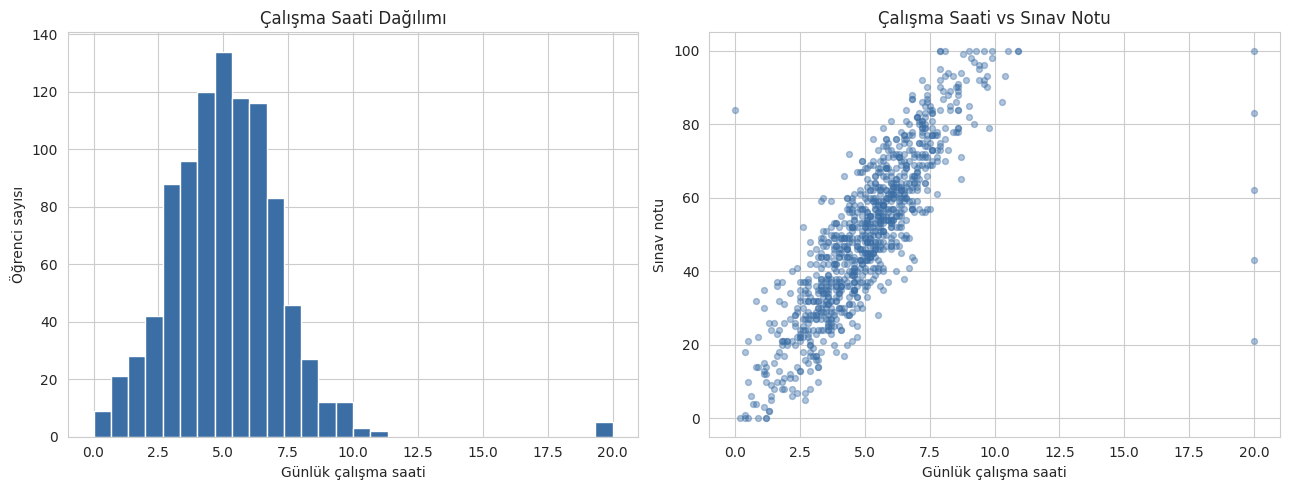

In [9]:
# ── Dağılımlar ve ilişki ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["Study_Hours"], bins=30, color="#3b6ea5", edgecolor="white")
axes[0].set_xlabel("Günlük çalışma saati")
axes[0].set_ylabel("Öğrenci sayısı")
axes[0].set_title("Çalışma Saati Dağılımı")

axes[1].scatter(df["Study_Hours"], df["Test_Score"], alpha=0.4, s=18, color="#3b6ea5")
axes[1].set_xlabel("Günlük çalışma saati")
axes[1].set_ylabel("Sınav notu")
axes[1].set_title("Çalışma Saati vs Sınav Notu")

plt.tight_layout()
plt.show()

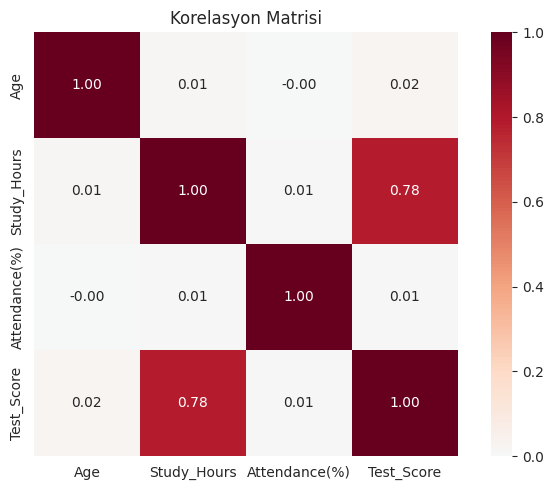

In [10]:
# ── Korelasyon ısı haritası ──────────────────────────────────────────────
sayisal = df[["Age", "Study_Hours", "Attendance(%)", "Test_Score"]]
plt.figure(figsize=(7, 5))
sns.heatmap(sayisal.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()
# Not: Pearson korelasyonu DOĞRUSAL ilişkiyi ölçer. Study_Hours-Test_Score korelasyonu 0.66
# görünüyor ama ilişki aslında daha güçlü - sadece doğrusal olmadığı için korelasyon "az" gösteriyor.

In [11]:
X = df[["Study_Hours"]].values
y = df["Test_Score"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Eğitim: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Eğitim: 769 | Test: 193


In [12]:
# Dersteki gibi dönüşümü somut görelim: x -> [1, x, x²]
ornek = np.array([[2], [5], [10]])
donusum = PolynomialFeatures(degree=2).fit_transform(ornek)
print("Girdi x:\n", ornek.ravel())
print("\nPolynomialFeatures(degree=2) çıktısı [1, x, x²]:\n", donusum)

Girdi x:
 [ 2  5 10]

PolynomialFeatures(degree=2) çıktısı [1, x, x²]:
 [[  1.   2.   4.]
 [  1.   5.  25.]
 [  1.  10. 100.]]


In [13]:
# ── Model eğitimi döngüsü (dersteki pipeline yaklaşımı) ──────────────────
dereceler = [1, 2, 3, 4, 5]
modeller, sonuclar = {}, []

for d in dereceler:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train, y_train)
    modeller[d] = model

    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)
    sonuclar.append({
        "Derece": d,
        "Egitim_R2": r2_score(y_train, y_pred_tr),
        "Test_R2":   r2_score(y_test, y_pred_te),
        "Test_MAE":  mean_absolute_error(y_test, y_pred_te),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_te)),
    })

sonuc_df = pd.DataFrame(sonuclar).round(4)
sonuc_df

,Derece,Egitim_R2,Test_R2,Test_MAE,Test_RMSE
0,1,0.6033,0.6379,9.7022,14.0522
1,2,0.7248,0.7960,8.5760,10.5482
2,3,0.7521,0.8308,7.8621,9.6054
3,4,0.7530,0.8310,7.9064,9.6003
4,5,0.7530,0.8313,7.8907,9.5905


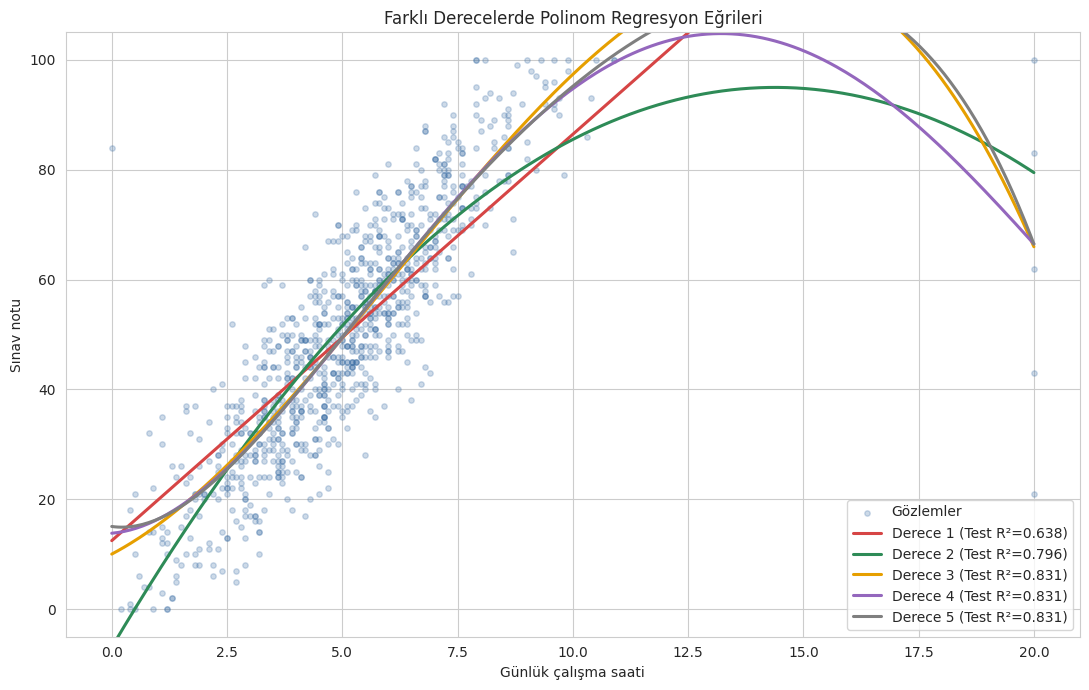

In [14]:
# ── Regresyon eğrilerinin görselleştirilmesi ─────────────────────────────
xs = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
renkler = {1: "#d64545", 2: "#2e8b57", 3: "#e69f00", 4: "#9467bd", 5: "#7f7f7f"}

plt.figure(figsize=(11, 7))
plt.scatter(X, y, alpha=0.25, s=15, color="#3b6ea5", label="Gözlemler")
for d in dereceler:
    plt.plot(xs, modeller[d].predict(xs), linewidth=2.2, color=renkler[d],
             label=f"Derece {d} (Test R²={sonuc_df.loc[sonuc_df.Derece==d,'Test_R2'].values[0]:.3f})")
plt.xlabel("Günlük çalışma saati")
plt.ylabel("Sınav notu")
plt.title("Farklı Derecelerde Polinom Regresyon Eğrileri")
plt.ylim(-5, 105)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ── K-Fold Cross-Validation ──────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_ozet = []
for d in dereceler:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    skorlar = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2")
    cv_ozet.append({"Derece": d, "CV_R2_Ortalama": skorlar.mean(), "CV_R2_Std": skorlar.std()})

cv_df = pd.DataFrame(cv_ozet).round(4)
print(cv_df.to_string(index=False))

en_iyi_derece = int(cv_df.loc[cv_df["CV_R2_Ortalama"].idxmax(), "Derece"])
print(f"\n🏆 CV'ye göre en iyi derece: {en_iyi_derece}")

 Derece  CV_R2_Ortalama  CV_R2_Std
      1          0.5767     0.1512
      2          0.7159     0.0540
      3          0.7443     0.0415
      4          0.7434     0.0415
      5          0.7393     0.0433

🏆 CV'ye göre en iyi derece: 3


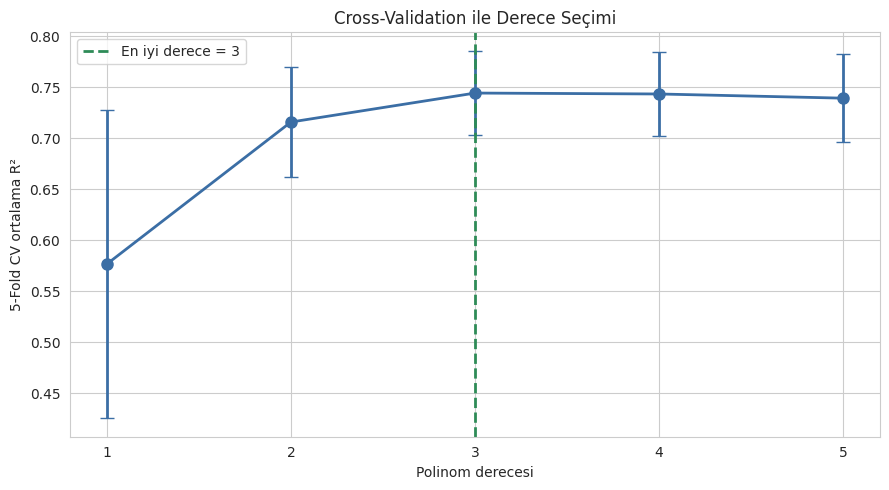

In [16]:
# ── CV sonuçlarının görselleştirilmesi ───────────────────────────────────
plt.figure(figsize=(9, 5))
plt.errorbar(cv_df["Derece"], cv_df["CV_R2_Ortalama"], yerr=cv_df["CV_R2_Std"],
             marker="o", markersize=8, capsize=5, color="#3b6ea5", linewidth=2)
plt.axvline(en_iyi_derece, color="#2e8b57", linestyle="--", linewidth=2,
            label=f"En iyi derece = {en_iyi_derece}")
plt.xlabel("Polinom derecesi")
plt.ylabel("5-Fold CV ortalama R²")
plt.title("Cross-Validation ile Derece Seçimi")
plt.xticks(dereceler)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# ── En iyi modeli tüm eğitim verisiyle eğitip test setinde değerlendir ───
en_iyi_model = make_pipeline(PolynomialFeatures(degree=en_iyi_derece), LinearRegression())
en_iyi_model.fit(X_train, y_train)
y_pred = en_iyi_model.predict(X_test)

print(f"Seçilen derece : {en_iyi_derece}")
print(f"Test R²        : {r2_score(y_test, y_pred):.4f}")
print(f"Test MAE       : {mean_absolute_error(y_test, y_pred):.2f} puan")
print(f"Test RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} puan")

# Doğrusal modelle kıyas
lin_r2 = sonuc_df.loc[sonuc_df.Derece == 1, "Test_R2"].values[0]
print(f"\nKarşılaştırma: doğrusal modelin Test R²'si {lin_r2:.4f} idi ->",
      f"polinom model farkı: +{r2_score(y_test, y_pred) - lin_r2:.4f}")

Seçilen derece : 3
Test R²        : 0.8308
Test MAE       : 7.86 puan
Test RMSE      : 9.61 puan

Karşılaştırma: doğrusal modelin Test R²'si 0.6379 idi -> polinom model farkı: +0.1929


In [18]:
# ── Katsayıların incelenmesi ─────────────────────────────────────────────
poly_adim = en_iyi_model.named_steps["polynomialfeatures"]
lr_adim   = en_iyi_model.named_steps["linearregression"]

isimler = poly_adim.get_feature_names_out(["saat"])
print("Model denklemi (katsayılar):")
print(f"  sabit (b0) = {lr_adim.intercept_:.3f}")
for isim, k in zip(isimler[1:], lr_adim.coef_[1:]):
    print(f"  {isim:<8} katsayı = {k:.3f}")

# Tepe noktası: eğrinin maksimuma ulaştığı çalışma saati (her derece için sayısal olarak)
izgara = np.linspace(0, X.max(), 1000).reshape(-1, 1)
tahminler = en_iyi_model.predict(izgara)
tepe_saat = izgara[tahminler.argmax()][0]
print(f"\n📌 Modelin bulduğu OPTİMUM çalışma saati: {tepe_saat:.1f} saat/gün")
print(f"   Bu noktadaki tahmini not: {tahminler.max():.1f}")

Model denklemi (katsayılar):
  sabit (b0) = 10.040
  saat     katsayı = 4.425
  saat^2   katsayı = 0.943
  saat^3   katsayı = -0.051

📌 Modelin bulduğu OPTİMUM çalışma saati: 14.3 saat/gün
   Bu noktadaki tahmini not: 116.3


In [19]:
def not_tahmin_et(saat):
    """Günlük çalışma saatine göre beklenen sınav notunu tahmin eder."""
    if not (0 <= saat <= 24):
        return "Geçersiz değer: çalışma saati 0-24 arasında olmalı!"
    tahmin = en_iyi_model.predict([[saat]])[0]
    return round(float(np.clip(tahmin, 0, 100)), 1)

for s in [1, 3, 5, 8, 10, 12, 15, 20]:
    print(f"Günde {s:>2} saat çalışan öğrencinin beklenen notu: {not_tahmin_et(s)}")

Günde  1 saat çalışan öğrencinin beklenen notu: 15.4
Günde  3 saat çalışan öğrencinin beklenen notu: 30.4
Günde  5 saat çalışan öğrencinin beklenen notu: 49.3
Günde  8 saat çalışan öğrencinin beklenen notu: 79.6
Günde 10 saat çalışan öğrencinin beklenen notu: 97.3
Günde 12 saat çalışan öğrencinin beklenen notu: 100.0
Günde 15 saat çalışan öğrencinin beklenen notu: 100.0
Günde 20 saat çalışan öğrencinin beklenen notu: 66.0
